# FlashAttention Inference Benchmark
### Vizuara AI Labs - Inference Engineering Workshop

This notebook benchmarks three attention implementations that map directly to the concepts from our visual walkthroughs:

- **Manual / standard causal attention**: materializes the full `N x N` score matrix in HBM; this is the baseline that FlashAttention was designed to avoid.
- **FlashAttention-2**: PyTorch SDPA forced onto the flash backend.
- **FlashAttention-3**: Hopper-native FA3 kernels from Dao-AILab's `flash-attention/hopper` package, used on H100/H200 (`sm_90`) GPUs.

Benchmark run target: **RunPod H200, CUDA 12.4, PyTorch 2.4.1+cu124**.

**Hardware note:** FlashAttention-3 requires a Hopper-class NVIDIA GPU, such as an **H100** or **H200** (`sm_90`), plus CUDA 12.3 or newer. It will not run on older GPUs like A100, L4, T4, or V100. FlashAttention-2 is more broadly available on Ampere-or-newer NVIDIA GPUs (`sm_80+`) through PyTorch SDPA. The RunPod benchmark in this notebook was executed on an **NVIDIA H200**, so FA3 is enabled here.


---
## What Are We Doing In This Notebook?

In this notebook, we are not loading a full pre-trained language model like Llama, GPT, or Mistral. Instead, we build a controlled attention benchmark that looks like the attention block inside a transformer model. The weights are randomly initialized, and the inputs are fake token embeddings with realistic LLM-like shapes. This lets us isolate one important part of inference, the causal self-attention computation, and compare how different attention implementations behave on the same GPU.

During inference, a real LLM first turns input text into token IDs, then converts those token IDs into embedding vectors. In this notebook, we start from that embedding stage directly. For example, a tensor shaped `(batch_size, sequence_length, embedding_dim)` represents a batch of prompts, where each position is one token vector. The attention layer projects each token vector into queries, keys, and values, then applies causal attention so each token can look only at itself and earlier tokens, not future tokens. We benchmark three ways of doing that same causal attention: manual attention, FlashAttention-2 through PyTorch SDPA, and FlashAttention-3 through the Hopper/H200 FA3 kernel.

The point is not to measure the full speed of an end-to-end chatbot. The point is to measure the part of transformer inference that becomes expensive for long prompts: attention over many tokens. By keeping the model shape fixed and changing sequence length or batch size, we can see exactly how latency and memory change as the context becomes larger.


## 0. Setup & GPU Check

In [1]:
# Optional FA3 setup for a fresh H100/H200 RunPod.
# The official Hopper package is installed from Dao-AILab/flash-attention/hopper
# and imported as `flash_attn_interface`.
#
# Important: a default FA3 source build can compile hundreds of kernels and take a very long time.
# This notebook benchmarks inference-only FP16 attention with head_dim=64, so we use a targeted
# forward-only build that is much faster on a fresh pod.
import importlib.util
import os
import pathlib
import subprocess
import sys
import torch


def ensure_flash_attention_3():
    if importlib.util.find_spec("flash_attn_interface") is not None:
        print("FlashAttention-3 package already available: flash_attn_interface")
        return

    if not torch.cuda.is_available():
        print("CUDA is not available; skipping FA3 install.")
        return

    capability = torch.cuda.get_device_capability(0)
    sm_version = capability[0] * 10 + capability[1]
    if sm_version < 90:
        print(f"GPU is sm_{sm_version}; FA3 requires Hopper sm_90 (H100/H200).")
        return

    print("Installing FlashAttention-3 from Dao-AILab/flash-attention/hopper ...")
    print("Using targeted inference-only build flags to avoid the full 293-kernel build.")

    env = os.environ.copy()
    cuda_home = env.get("CUDA_HOME") or "/usr/local/cuda-12.4"
    env["CUDA_HOME"] = cuda_home
    env["PATH"] = f"{cuda_home}/bin:" + env.get("PATH", "")
    env.setdefault("MAX_JOBS", "8")

    # Target this notebook's benchmark: FP16 forward, head_dim=64, Hopper only.
    env.update({
        "FLASH_ATTENTION_DISABLE_BACKWARD": "TRUE",
        "FLASH_ATTENTION_DISABLE_SM80": "TRUE",
        "FLASH_ATTENTION_DISABLE_FP8": "TRUE",
        "FLASH_ATTENTION_DISABLE_VARLEN": "TRUE",
        "FLASH_ATTENTION_DISABLE_PAGEDKV": "TRUE",
        "FLASH_ATTENTION_DISABLE_APPENDKV": "TRUE",
        "FLASH_ATTENTION_DISABLE_LOCAL": "TRUE",
        "FLASH_ATTENTION_DISABLE_SOFTCAP": "TRUE",
        "FLASH_ATTENTION_DISABLE_PACKGQA": "TRUE",
        "FLASH_ATTENTION_DISABLE_HDIM96": "TRUE",
        "FLASH_ATTENTION_DISABLE_HDIM128": "TRUE",
        "FLASH_ATTENTION_DISABLE_HDIM192": "TRUE",
        "FLASH_ATTENTION_DISABLE_HDIM256": "TRUE",
    })

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-U",
        "pip", "setuptools", "wheel", "packaging", "ninja", "psutil",
    ], env=env)

    repo = pathlib.Path("/workspace/flash-attention")
    if not repo.exists():
        subprocess.check_call(["git", "clone", "https://github.com/Dao-AILab/flash-attention.git", str(repo)], env=env)

    hopper_dir = repo / "hopper"
    for name in ("build", "dist", "flash_attn_3.egg-info"):
        path = hopper_dir / name
        if path.exists():
            subprocess.run(["rm", "-rf", str(path)], check=True)

    subprocess.check_call([sys.executable, "setup.py", "install"], cwd=hopper_dir, env=env)
    print("FlashAttention-3 install complete. Restart the kernel if import still fails.")

# Leave this as an explicit call so reruns on an already-prepared pod are fast.
ensure_flash_attention_3()


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import platform

# GPU info
assert torch.cuda.is_available(), "This notebook requires a CUDA GPU!"
device = torch.device("cuda")

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)
sm_version = gpu_capability[0] * 10 + gpu_capability[1]

print(f"Python          : {platform.python_version()}")
print(f"PyTorch version : {torch.__version__}")
print(f"GPU             : {gpu_name}")
print(f"SM version      : sm_{sm_version}")
print(f"CUDA version    : {torch.version.cuda}")
gpu_props = torch.cuda.get_device_properties(0)
gpu_memory_bytes = getattr(gpu_props, "total_memory", getattr(gpu_props, "total_mem", 0))
print(f"Memory          : {gpu_memory_bytes / 1e9:.1f} GB")
print()

HAS_FA2 = sm_version >= 80
HAS_FA3 = False
FA3_IMPORT_ERROR = None

if sm_version >= 90:
    try:
        import flash_attn_interface as fa3_interface
        flash_attn_3_func = fa3_interface.flash_attn_func
        HAS_FA3 = True
        print("FlashAttention-3 : Available via flash_attn_interface")
    except Exception as exc:
        FA3_IMPORT_ERROR = repr(exc)
        print(f"FlashAttention-3 : Not importable yet ({FA3_IMPORT_ERROR})")
        print("Run ensure_flash_attention_3() in the setup cell, then restart/re-run this cell.")
else:
    print(f"FlashAttention-3 : Not available (needs SM90/H100/H200, you have sm_{sm_version})")

print(f"FlashAttention-2 : {'Available' if HAS_FA2 else 'Not available (needs SM80+)'}")

# Enable tensor cores
torch.set_float32_matmul_precision("high")


Python          : 3.11.10
PyTorch version : 2.4.1+cu124
GPU             : NVIDIA H200
SM version      : sm_90
CUDA version    : 12.4
Memory          : 150.1 GB

FlashAttention-3 : Available via flash_attn_interface
FlashAttention-2 : Available


---
## 1. Manual Causal Attention (Standard / No Flash)

This is the textbook implementation — the one we traced in the **Normal Attention HBM Walkthrough**:

```
S = Q @ K^T / √d        →  written to HBM (N×N floats)
S = mask(S, -inf)        →  causal mask applied
P = softmax(S)           →  read S from HBM, write P back
O = P @ V                →  read P from HBM, compute output
```

**The problem:** For sequence length N=8192 and d=64, the intermediate S matrix alone is **512 MB in FP32**. At N=32K, it's **8 GB**. This HBM traffic is the bottleneck — the GPU spends most of its time waiting for memory, not computing.

**HBM I/O complexity:** O(N² + Nd) — quadratic in sequence length.

In [3]:
class ManualCausalAttention(nn.Module):
    """Standard attention — materializes full N×N score matrix in HBM."""

    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.d_out = d_out

        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
        self.proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        B, N, _ = x.shape

        # Project Q, K, V
        qkv = self.qkv(x)
        qkv = qkv.view(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, H, N, D)
        queries, keys, values = qkv.unbind(0)

        # S = QK^T / √d  — full N×N matrix materialized in HBM
        attn_scores = queries @ keys.transpose(-2, -1)  # (B, H, N, N)
        attn_scores = attn_scores / math.sqrt(self.head_dim)

        # Causal mask
        attn_scores.masked_fill_(self.mask[:N, :N].bool(), float("-inf"))

        # P = softmax(S) — read S from HBM, write P to HBM
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # O = PV — read P from HBM
        out = attn_weights @ values  # (B, H, N, D)
        out = out.transpose(1, 2).contiguous().view(B, N, self.d_out)
        return self.proj(out)


---
## What Is SDPA?

SDPA means **Scaled Dot Product Attention**. In PyTorch, `torch.nn.functional.scaled_dot_product_attention` is the standard high-level attention API used by many modern transformer implementations. You call one PyTorch function with query, key, and value tensors, and PyTorch chooses an optimized backend when possible.

So SDPA is not exactly the separate `flash-attn` Python package. It is PyTorch's built-in attention interface. On supported NVIDIA GPUs, PyTorch SDPA can dispatch to a FlashAttention-style CUDA kernel, which is why this notebook labels it as FlashAttention-2. In plain English: SDPA is the standard PyTorch way to ask for attention these days, and on modern GPUs it often runs a flash attention backend automatically or when we force the flash backend explicitly. FlashAttention-3 is different here because it comes from Dao-AILab's Hopper-specific FA3 package and is optimized for H100/H200 class GPUs.


---
## 2. FlashAttention-2 (PyTorch Built-in SDPA)

Since PyTorch 2.2, `F.scaled_dot_product_attention` uses **FlashAttention-2** automatically when:
- `is_causal=True` (no explicit mask needed)
- Input is on CUDA with SM80+ (A100, H100)
- dtype is `float16` or `bfloat16`

**What changes from standard attention (as covered in our FA step-by-step walkthrough):**
- Q, K, V are split into SRAM-sized blocks (tiles)
- Score tiles are computed **in SRAM** and never written to HBM
- Online softmax with correction factors combines partial results
- Output O is written to HBM only **once per Q block**

**FA2-specific optimizations (from our FA2/FA3 evolution walkthrough):**
- **Reversed loop order:** Outer loop over Q blocks (not KV) → each Q block is independent → parallel across SMs
- **Split-Q warp partitioning:** Zero inter-warp synchronization
- **Deferred softmax rescaling:** Fewer non-matmul FLOPs

**HBM I/O complexity:** O(N²d / M) where M = SRAM size — sub-quadratic!

In [4]:
from torch.nn.attention import SDPBackend, sdpa_kernel


class FlashAttention2(nn.Module):
    """FlashAttention-2 via PyTorch's built-in SDPA.

    Identical interface to ManualCausalAttention, but uses
    F.scaled_dot_product_attention with is_causal=True, which
    triggers the FlashAttention-2 kernel on SM80+ GPUs.
    """

    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.d_out = d_out

        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
        self.proj = nn.Linear(d_out, d_out)
        self.dropout = dropout

    def forward(self, x):
        B, N, _ = x.shape

        qkv = self.qkv(x)
        qkv = qkv.view(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        queries, keys, values = qkv.unbind(0)

        drop_p = 0.0 if not self.training else self.dropout

        # Force FlashAttention-2 backend only
        with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
            out = F.scaled_dot_product_attention(
                queries, keys, values,
                attn_mask=None,
                dropout_p=drop_p,
                is_causal=True,  # no explicit mask needed — FA2 handles it
            )

        out = out.transpose(1, 2).contiguous().view(B, N, self.d_out)
        return self.proj(out)


---
## 3. FlashAttention-3 (Hopper-Native, H100 Only)

FA3 is **not** a PyTorch built-in — it's installed separately via `pip install flash-attn-3`. It requires an **H100 GPU (SM90)**.

**What FA3 adds on top of FA2 (from our FA2/FA3 evolution walkthrough):**
- **TMA (Tensor Memory Accelerator):** Async data movement from HBM → SRAM without using compute threads
- **WGMMA:** Warp-group matrix multiply at 989 TFLOPs/s (FP16) — 1.5× over Ampere's mma.sync
- **Producer-consumer pipeline:** Producer warps load next KV block while consumer warps compute on current block
- **Ping-pong scheduling:** Two warpgroups alternate GEMMs and softmax — hides the 256× throughput gap for exp/max operations
- **FP8 support:** With incoherent processing (Hadamard transform) for 2× throughput at 2.6× lower error than naive FP8

**Performance:** ~75% of H100 peak FP16 (740 TFLOPs/s) vs FA2's ~35% on H100.

In [5]:
class FlashAttention3(nn.Module):
    """FlashAttention-3 via Dao-AILab's Hopper package.

    The official FA3 beta installs a top-level `flash_attn_interface` module.
    It expects Q/K/V in (B, N, H, D) layout.
    """

    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.d_out = d_out

        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
        self.proj = nn.Linear(d_out, d_out)

    def forward(self, x):
        B, N, _ = x.shape

        qkv = self.qkv(x)
        qkv = qkv.view(B, N, 3, self.num_heads, self.head_dim)
        queries, keys, values = qkv.unbind(2)  # each: (B, N, H, D)

        out = flash_attn_3_func(queries, keys, values, causal=True)
        if isinstance(out, tuple):
            out = out[0]

        out = out.contiguous().view(B, N, self.d_out)
        return self.proj(out)


if not HAS_FA3:
    print("FlashAttention-3 not available - FA3 benchmarks will be skipped until setup succeeds.")
    if FA3_IMPORT_ERROR:
        print(f"Import error: {FA3_IMPORT_ERROR}")


---
## 4. Sanity Check: Numerical Correctness

All three implementations must produce the **same output** (within floating-point tolerance). FlashAttention is *exact* — not an approximation. The online softmax correction factors ensure bit-level equivalence with standard attention.

In [6]:
# Use a small size for correctness check
torch.manual_seed(42)
check_cfg = dict(d_in=768, d_out=768, num_heads=12, context_length=128, dropout=0.0, qkv_bias=False)

manual_attn = ManualCausalAttention(**check_cfg).to(device).half()
fa2_attn    = FlashAttention2(**check_cfg).to(device).half()

# Share the same weights
with torch.no_grad():
    fa2_attn.qkv.weight.copy_(manual_attn.qkv.weight)
    fa2_attn.qkv.bias = manual_attn.qkv.bias
    fa2_attn.proj.weight.copy_(manual_attn.proj.weight)
    fa2_attn.proj.bias.copy_(manual_attn.proj.bias)

x_check = torch.randn(2, 128, 768, device=device, dtype=torch.float16)

with torch.no_grad():
    out_manual = manual_attn(x_check)
    out_fa2    = fa2_attn(x_check)

diff_fa2 = (out_manual - out_fa2).abs().max().item()
print(f"Manual vs FA2  max abs diff: {diff_fa2:.6f}")

if HAS_FA3:
    fa3_attn = FlashAttention3(**check_cfg).to(device).half()
    with torch.no_grad():
        fa3_attn.qkv.weight.copy_(manual_attn.qkv.weight)
        fa3_attn.qkv.bias = manual_attn.qkv.bias
        fa3_attn.proj.weight.copy_(manual_attn.proj.weight)
        fa3_attn.proj.bias.copy_(manual_attn.proj.bias)
        out_fa3 = fa3_attn(x_check)
    diff_fa3 = (out_manual - out_fa3).abs().max().item()
    print(f"Manual vs FA3  max abs diff: {diff_fa3:.6f}")

print("\n(Diffs should be < 0.01 — any difference is from FP16 accumulation order, not algorithmic error)")


Manual vs FA2  max abs diff: 0.000488
Manual vs FA3  max abs diff: 0.000488

(Diffs should be < 0.01 — any difference is from FP16 accumulation order, not algorithmic error)


---
## 5. Inference Benchmarking Utilities

We benchmark **inference only** (forward pass, no gradients) — this is what matters for LLM serving.

The timing uses CUDA events for accurate GPU measurement with proper warmup, following the pattern from Raschka's benchmark code.

In [7]:
@torch.no_grad()
def benchmark_inference(func, *inputs, num_warmup=10, num_repeats=100):
    """Benchmark a function using CUDA events (accurate GPU timing).

    Returns (mean_ms, std_ms).
    """
    for _ in range(num_warmup):
        func(*inputs)
    torch.cuda.synchronize()

    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    times = []
    for _ in range(num_repeats):
        start_event.record()
        func(*inputs)
        end_event.record()
        torch.cuda.synchronize()
        times.append(start_event.elapsed_time(end_event))

    return np.mean(times), np.std(times)


def repeats_for(seq_len, batch_size):
    """Keep long manual-attention runs practical while preserving stable measurements."""
    work = seq_len * batch_size
    if work >= 65536:
        return 5, 20
    if work >= 32768:
        return 5, 30
    if work >= 16384:
        return 8, 50
    return 10, 100


def measure_peak_memory(func, *inputs):
    """Measure peak GPU memory allocated during a forward pass."""
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    with torch.no_grad():
        func(*inputs)

    torch.cuda.synchronize()
    peak_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
    return peak_mb


# Model config (Llama-style structure, scaled down enough to benchmark interactively)
EMBED_DIM  = 768
NUM_HEADS  = 12
BATCH_SIZE = 8
DTYPE      = torch.float16

# Sequence lengths to benchmark - the key axis for showing FA2/FA3 advantage
SEQ_LENGTHS = [256, 512, 1024, 2048, 4096, 8192]

print(f"Config: embed_dim={EMBED_DIM}, heads={NUM_HEADS}, batch={BATCH_SIZE}, dtype={DTYPE}")
print(f"Sequence lengths: {SEQ_LENGTHS}")


Config: embed_dim=768, heads=12, batch=8, dtype=torch.float16
Sequence lengths: [256, 512, 1024, 2048, 4096, 8192]


---
## 6. Benchmark: Latency vs Sequence Length

This is the most important plot for inference. As sequence length grows, standard attention's O(N²) HBM traffic makes it increasingly slow relative to FlashAttention. This directly impacts **time-to-first-token (TTFT)** during prefill.

In [8]:
results = {"Manual Attention": [], "FlashAttention-2": []}
if HAS_FA3:
    results["FlashAttention-3"] = []

for seq_len in SEQ_LENGTHS:
    print(f"\n--- Sequence length: {seq_len} ---")
    cfg = dict(d_in=EMBED_DIM, d_out=EMBED_DIM, num_heads=NUM_HEADS,
               context_length=seq_len, dropout=0.0, qkv_bias=False)
    x = torch.randn(BATCH_SIZE, seq_len, EMBED_DIM, device=device, dtype=DTYPE)
    warmup, repeats = repeats_for(seq_len, BATCH_SIZE)
    print(f"  timing repeats: warmup={warmup}, repeats={repeats}")

    # Manual attention
    try:
        model_manual = ManualCausalAttention(**cfg).to(device).half().eval()
        mean_ms, std_ms = benchmark_inference(model_manual, x, num_warmup=warmup, num_repeats=repeats)
        results["Manual Attention"].append((seq_len, mean_ms, std_ms))
        print(f"  Manual     : {mean_ms:.2f} +/- {std_ms:.2f} ms")
        del model_manual
    except torch.cuda.OutOfMemoryError:
        results["Manual Attention"].append((seq_len, float("nan"), 0.0))
        print("  Manual     : OOM")
        torch.cuda.empty_cache()

    # FA2
    model_fa2 = FlashAttention2(**cfg).to(device).half().eval()
    mean_ms, std_ms = benchmark_inference(model_fa2, x, num_warmup=warmup, num_repeats=repeats)
    results["FlashAttention-2"].append((seq_len, mean_ms, std_ms))
    print(f"  FA2        : {mean_ms:.2f} +/- {std_ms:.2f} ms")
    del model_fa2

    # FA3
    if HAS_FA3:
        model_fa3 = FlashAttention3(**cfg).to(device).half().eval()
        mean_ms, std_ms = benchmark_inference(model_fa3, x, num_warmup=warmup, num_repeats=repeats)
        results["FlashAttention-3"].append((seq_len, mean_ms, std_ms))
        print(f"  FA3        : {mean_ms:.2f} +/- {std_ms:.2f} ms")
        del model_fa3

    del x
    torch.cuda.empty_cache()

print("\nBenchmark complete!")



--- Sequence length: 256 ---
  timing repeats: warmup=10, repeats=100


  Manual     : 0.18 +/- 0.01 ms
  FA2        : 0.10 +/- 0.00 ms
  FA3        : 0.58 +/- 0.01 ms

--- Sequence length: 512 ---
  timing repeats: warmup=10, repeats=100
  Manual     : 0.34 +/- 0.00 ms
  FA2        : 0.10 +/- 0.00 ms


  FA3        : 0.57 +/- 0.03 ms

--- Sequence length: 1024 ---
  timing repeats: warmup=10, repeats=100
  Manual     : 0.98 +/- 0.00 ms
  FA2        : 0.17 +/- 0.03 ms


  FA3        : 0.60 +/- 0.04 ms

--- Sequence length: 2048 ---
  timing repeats: warmup=8, repeats=50


  Manual     : 5.09 +/- 0.04 ms
  FA2        : 0.37 +/- 0.00 ms
  FA3        : 0.64 +/- 0.03 ms

--- Sequence length: 4096 ---
  timing repeats: warmup=5, repeats=30


  Manual     : 15.47 +/- 0.01 ms
  FA2        : 1.01 +/- 0.01 ms
  FA3        : 0.68 +/- 0.01 ms

--- Sequence length: 8192 ---
  timing repeats: warmup=5, repeats=20


  Manual     : 53.16 +/- 0.08 ms
  FA2        : 3.34 +/- 0.05 ms
  FA3        : 2.02 +/- 0.05 ms

Benchmark complete!


---
## 7. Benchmark: Peak Memory Usage

Standard attention allocates the full N×N score matrix in HBM. FlashAttention only allocates SRAM-sized tiles. This is the difference between being able to run 128K context and running out of memory at 16K.

In [9]:
mem_results = {"Manual Attention": [], "FlashAttention-2": []}
if HAS_FA3:
    mem_results["FlashAttention-3"] = []

mem_seq_lengths = [512, 1024, 2048, 4096, 8192]

for seq_len in mem_seq_lengths:
    cfg = dict(d_in=EMBED_DIM, d_out=EMBED_DIM, num_heads=NUM_HEADS,
               context_length=seq_len, dropout=0.0, qkv_bias=False)
    x = torch.randn(BATCH_SIZE, seq_len, EMBED_DIM, device=device, dtype=DTYPE)

    # Manual
    model = ManualCausalAttention(**cfg).to(device).half().eval()
    peak_mb = measure_peak_memory(model, x)
    mem_results["Manual Attention"].append((seq_len, peak_mb))
    del model

    # FA2
    model = FlashAttention2(**cfg).to(device).half().eval()
    peak_mb = measure_peak_memory(model, x)
    mem_results["FlashAttention-2"].append((seq_len, peak_mb))
    del model

    # FA3
    if HAS_FA3:
        model = FlashAttention3(**cfg).to(device).half().eval()
        peak_mb = measure_peak_memory(model, x)
        mem_results["FlashAttention-3"].append((seq_len, peak_mb))
        del model

    del x
    torch.cuda.empty_cache()

# Print summary table
print(f"{'Seq Len':>8}  {'Manual (MB)':>12}  {'FA2 (MB)':>10}", end="")
if HAS_FA3:
    print(f"  {'FA3 (MB)':>10}", end="")
print()
print("-" * 50)

for i, seq_len in enumerate(mem_seq_lengths):
    manual_mb = mem_results["Manual Attention"][i][1]
    fa2_mb    = mem_results["FlashAttention-2"][i][1]
    print(f"{seq_len:>8}  {manual_mb:>12.1f}  {fa2_mb:>10.1f}", end="")
    if HAS_FA3:
        fa3_mb = mem_results["FlashAttention-3"][i][1]
        print(f"  {fa3_mb:>10.1f}", end="")
    print()


 Seq Len   Manual (MB)    FA2 (MB)    FA3 (MB)
--------------------------------------------------
     512         186.8        90.3        90.3
    1024         510.8       124.7       124.7
    2048        1740.5       196.5       196.5
    4096        6516.5       340.5       340.5
    8192       25332.5       628.5       628.5


---
## 8. Benchmark: Fixed Sequence Length, Varying Batch Size

In inference serving, you often batch multiple requests together to improve GPU utilization. This benchmark shows how each attention variant scales with batch size at a fixed sequence length (2048 tokens — a typical prompt).

In [10]:
FIXED_SEQ_LEN = 2048
BATCH_SIZES = [1, 2, 4, 8, 16, 32]

batch_results = {"Manual Attention": [], "FlashAttention-2": []}
if HAS_FA3:
    batch_results["FlashAttention-3"] = []

for bs in BATCH_SIZES:
    print(f"\n--- Batch size: {bs} ---")
    cfg = dict(d_in=EMBED_DIM, d_out=EMBED_DIM, num_heads=NUM_HEADS,
               context_length=FIXED_SEQ_LEN, dropout=0.0, qkv_bias=False)
    x = torch.randn(bs, FIXED_SEQ_LEN, EMBED_DIM, device=device, dtype=DTYPE)
    warmup, repeats = repeats_for(FIXED_SEQ_LEN, bs)
    print(f"  timing repeats: warmup={warmup}, repeats={repeats}")

    try:
        model = ManualCausalAttention(**cfg).to(device).half().eval()
        mean_ms, std_ms = benchmark_inference(model, x, num_warmup=warmup, num_repeats=repeats)
        batch_results["Manual Attention"].append((bs, mean_ms, std_ms))
        print(f"  Manual     : {mean_ms:.2f} +/- {std_ms:.2f} ms")
        del model
    except torch.cuda.OutOfMemoryError:
        batch_results["Manual Attention"].append((bs, float("nan"), 0))
        print("  Manual     : OOM!")
        torch.cuda.empty_cache()

    model = FlashAttention2(**cfg).to(device).half().eval()
    mean_ms, std_ms = benchmark_inference(model, x, num_warmup=warmup, num_repeats=repeats)
    batch_results["FlashAttention-2"].append((bs, mean_ms, std_ms))
    print(f"  FA2        : {mean_ms:.2f} +/- {std_ms:.2f} ms")
    del model

    if HAS_FA3:
        model = FlashAttention3(**cfg).to(device).half().eval()
        mean_ms, std_ms = benchmark_inference(model, x, num_warmup=warmup, num_repeats=repeats)
        batch_results["FlashAttention-3"].append((bs, mean_ms, std_ms))
        print(f"  FA3        : {mean_ms:.2f} +/- {std_ms:.2f} ms")
        del model

    del x
    torch.cuda.empty_cache()

print("\nBatch size benchmark complete!")



--- Batch size: 1 ---
  timing repeats: warmup=10, repeats=100
  Manual     : 0.71 +/- 0.00 ms
  FA2        : 0.12 +/- 0.00 ms


  FA3        : 0.58 +/- 0.03 ms

--- Batch size: 2 ---
  timing repeats: warmup=10, repeats=100
  Manual     : 1.34 +/- 0.00 ms


  FA2        : 0.15 +/- 0.02 ms
  FA3        : 0.56 +/- 0.01 ms

--- Batch size: 4 ---
  timing repeats: warmup=10, repeats=100


  Manual     : 2.58 +/- 0.00 ms
  FA2        : 0.22 +/- 0.00 ms
  FA3        : 0.56 +/- 0.01 ms

--- Batch size: 8 ---
  timing repeats: warmup=8, repeats=50


  Manual     : 5.07 +/- 0.00 ms
  FA2        : 0.37 +/- 0.00 ms
  FA3        : 0.57 +/- 0.01 ms

--- Batch size: 16 ---
  timing repeats: warmup=5, repeats=30


  Manual     : 10.04 +/- 0.01 ms
  FA2        : 0.65 +/- 0.00 ms
  FA3        : 0.59 +/- 0.01 ms

--- Batch size: 32 ---
  timing repeats: warmup=5, repeats=20


  Manual     : 20.02 +/- 0.11 ms
  FA2        : 1.23 +/- 0.00 ms
  FA3        : 0.96 +/- 0.01 ms

Batch size benchmark complete!


---
## 9. Visualizations

### Plot styling

In [11]:
# --- Plot styling (dark theme matching Raschka's notebook) ---
plt.rcParams.update({
    "figure.facecolor": "#121212", "axes.facecolor": "#121212",
    "axes.edgecolor": "white", "axes.labelcolor": "white",
    "text.color": "white", "xtick.color": "white", "ytick.color": "white",
    "grid.color": "#333333", "grid.alpha": 0.5,
    "lines.linewidth": 2.5, "lines.markersize": 8,
    "legend.facecolor": "#1e1e1e", "legend.edgecolor": "#444444",
    "figure.figsize": (12, 6),
})

COLORS = {
    "Manual Attention": "#ef4444",   # red
    "FlashAttention-2": "#7c5cfc",   # purple (Vizuara brand)
    "FlashAttention-3": "#10b981",   # green
}

MARKERS = {
    "Manual Attention": "s",
    "FlashAttention-2": "o",
    "FlashAttention-3": "D",
}


### 9.1 Latency vs Sequence Length (Inference)

This is the core plot. Standard attention's latency grows **quadratically** with sequence length (the N×N matrix). FlashAttention's latency grows much more slowly because its HBM I/O scales as O(N²d/M), and the SRAM tile computations are fast.

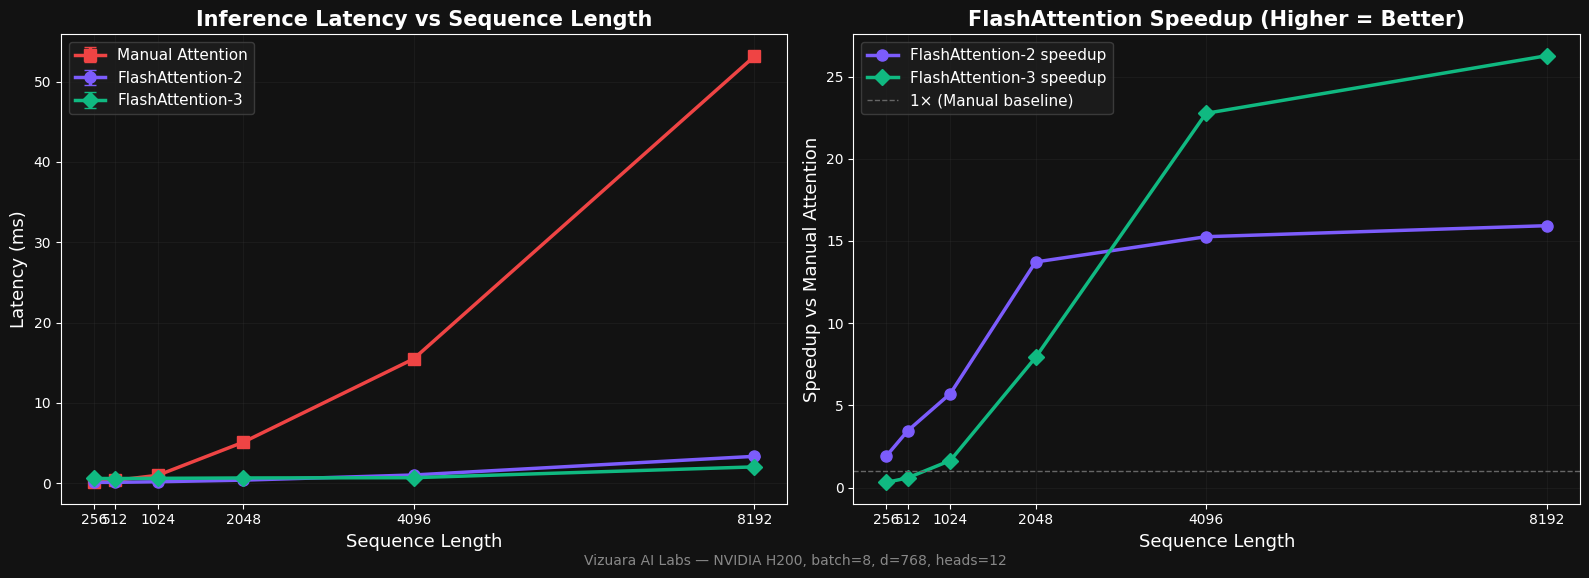

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Absolute latency ---
for name, data in results.items():
    seq_lens = [d[0] for d in data]
    means    = [d[1] for d in data]
    stds     = [d[2] for d in data]
    ax1.errorbar(seq_lens, means, yerr=stds, label=name,
                 color=COLORS[name], marker=MARKERS[name], capsize=4, linewidth=2.5)

ax1.set_xlabel("Sequence Length", fontsize=13)
ax1.set_ylabel("Latency (ms)", fontsize=13)
ax1.set_title("Inference Latency vs Sequence Length", fontsize=15, fontweight="bold")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(SEQ_LENGTHS)
ax1.set_xticklabels([str(s) for s in SEQ_LENGTHS])

# --- Right: Speedup relative to manual ---
manual_means = {d[0]: d[1] for d in results["Manual Attention"]}
for name, data in results.items():
    if name == "Manual Attention":
        continue
    seq_lens = [d[0] for d in data]
    speedups = [manual_means[d[0]] / d[1] for d in data]
    ax2.plot(seq_lens, speedups, label=f"{name} speedup",
             color=COLORS[name], marker=MARKERS[name], linewidth=2.5)

ax2.axhline(y=1, color="#666666", linestyle="--", linewidth=1, label="1× (Manual baseline)")
ax2.set_xlabel("Sequence Length", fontsize=13)
ax2.set_ylabel("Speedup vs Manual Attention", fontsize=13)
ax2.set_title("FlashAttention Speedup (Higher = Better)", fontsize=15, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(SEQ_LENGTHS)
ax2.set_xticklabels([str(s) for s in SEQ_LENGTHS])

fig.suptitle(f"Vizuara AI Labs — {gpu_name}, batch={BATCH_SIZE}, d={EMBED_DIM}, heads={NUM_HEADS}",
             fontsize=10, color="#888888", y=0.02)
plt.tight_layout()
plt.savefig("plot_latency_vs_seqlen.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.2 Peak Memory Usage vs Sequence Length

Memory is often the harder constraint in inference. Standard attention's O(N²) intermediate matrix means you **cannot even run** long sequences — you OOM before the GPU gets a chance to compute. FlashAttention's O(1) intermediates (just SRAM-sized tiles) make long contexts possible.

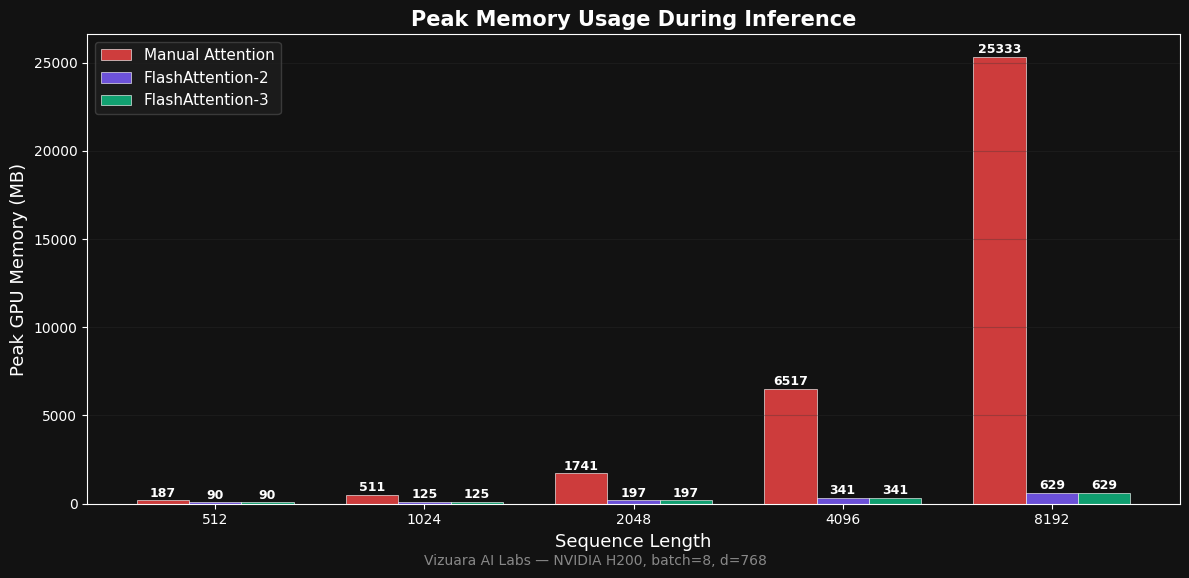

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.25
num_variants = len(mem_results)
x_pos = np.arange(len(mem_seq_lengths))

for i, (name, data) in enumerate(mem_results.items()):
    mems = [d[1] for d in data]
    offset = (i - (num_variants - 1) / 2) * bar_width
    bars = ax.bar(x_pos + offset, mems, bar_width, label=name,
                  color=COLORS[name], alpha=0.85, edgecolor="white", linewidth=0.5)
    # Add value labels on bars
    for bar, val in zip(bars, mems):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f"{val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("Sequence Length", fontsize=13)
ax.set_ylabel("Peak GPU Memory (MB)", fontsize=13)
ax.set_title("Peak Memory Usage During Inference", fontsize=15, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels([str(s) for s in mem_seq_lengths])
ax.legend(fontsize=11)
ax.grid(True, axis="y", alpha=0.3)

fig.suptitle(f"Vizuara AI Labs — {gpu_name}, batch={BATCH_SIZE}, d={EMBED_DIM}",
             fontsize=10, color="#888888", y=0.02)
plt.tight_layout()
plt.savefig("plot_memory_usage.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.3 Latency vs Batch Size (Fixed Seq Length = 2048)

In production inference serving (vLLM, TensorRT-LLM, SGLang), requests are batched to maximize GPU utilization. This shows how throughput scales with concurrent requests.

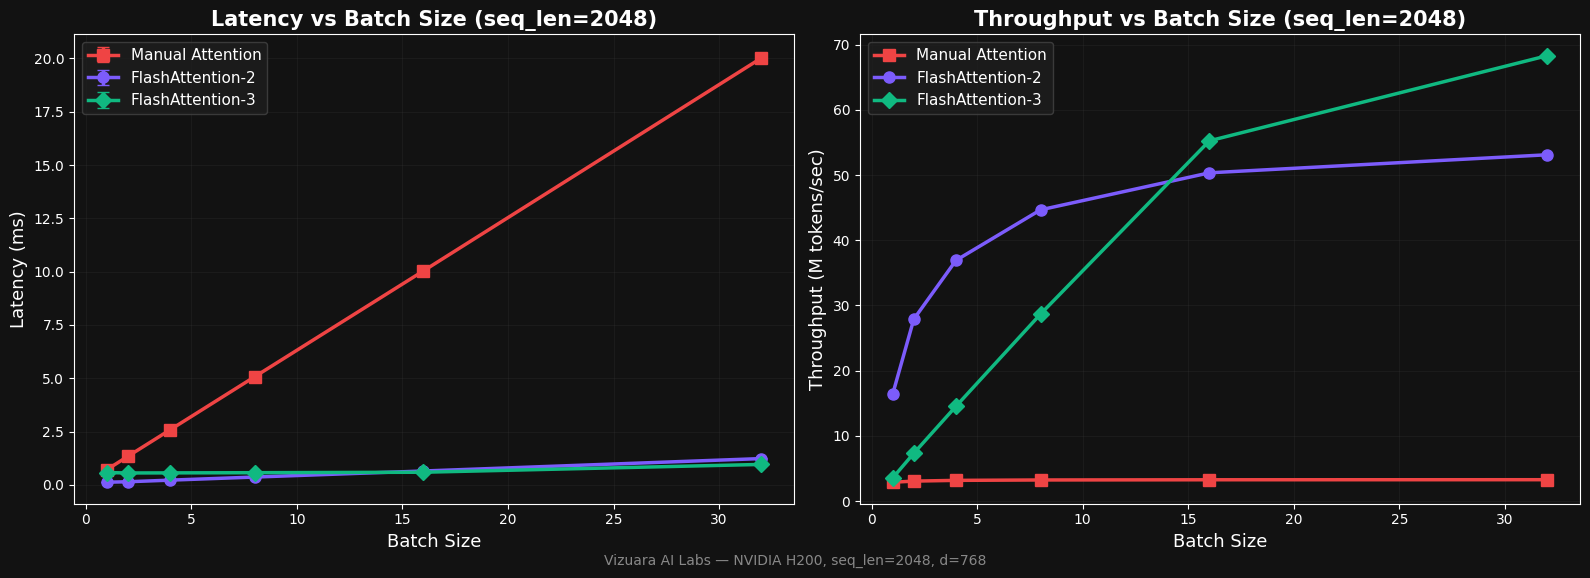

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Latency vs batch size ---
for name, data in batch_results.items():
    bs_vals = [d[0] for d in data]
    means   = [d[1] for d in data]
    stds    = [d[2] for d in data]
    ax1.errorbar(bs_vals, means, yerr=stds, label=name,
                 color=COLORS[name], marker=MARKERS[name], capsize=4, linewidth=2.5)

ax1.set_xlabel("Batch Size", fontsize=13)
ax1.set_ylabel("Latency (ms)", fontsize=13)
ax1.set_title(f"Latency vs Batch Size (seq_len={FIXED_SEQ_LEN})", fontsize=15, fontweight="bold")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Right: Throughput (tokens/sec) ---
for name, data in batch_results.items():
    bs_vals    = [d[0] for d in data]
    throughput = [(d[0] * FIXED_SEQ_LEN) / (d[1] / 1000) for d in data if not np.isnan(d[1])]
    valid_bs   = [d[0] for d in data if not np.isnan(d[1])]
    ax2.plot(valid_bs, [t / 1e6 for t in throughput], label=name,
             color=COLORS[name], marker=MARKERS[name], linewidth=2.5)

ax2.set_xlabel("Batch Size", fontsize=13)
ax2.set_ylabel("Throughput (M tokens/sec)", fontsize=13)
ax2.set_title(f"Throughput vs Batch Size (seq_len={FIXED_SEQ_LEN})", fontsize=15, fontweight="bold")
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Vizuara AI Labs — {gpu_name}, seq_len={FIXED_SEQ_LEN}, d={EMBED_DIM}",
             fontsize=10, color="#888888", y=0.02)
plt.tight_layout()
plt.savefig("plot_batch_scaling.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.4 Combined Bar Chart: All Sequence Lengths Side-by-Side

A single at-a-glance comparison, similar to the visualization in Raschka's notebook.

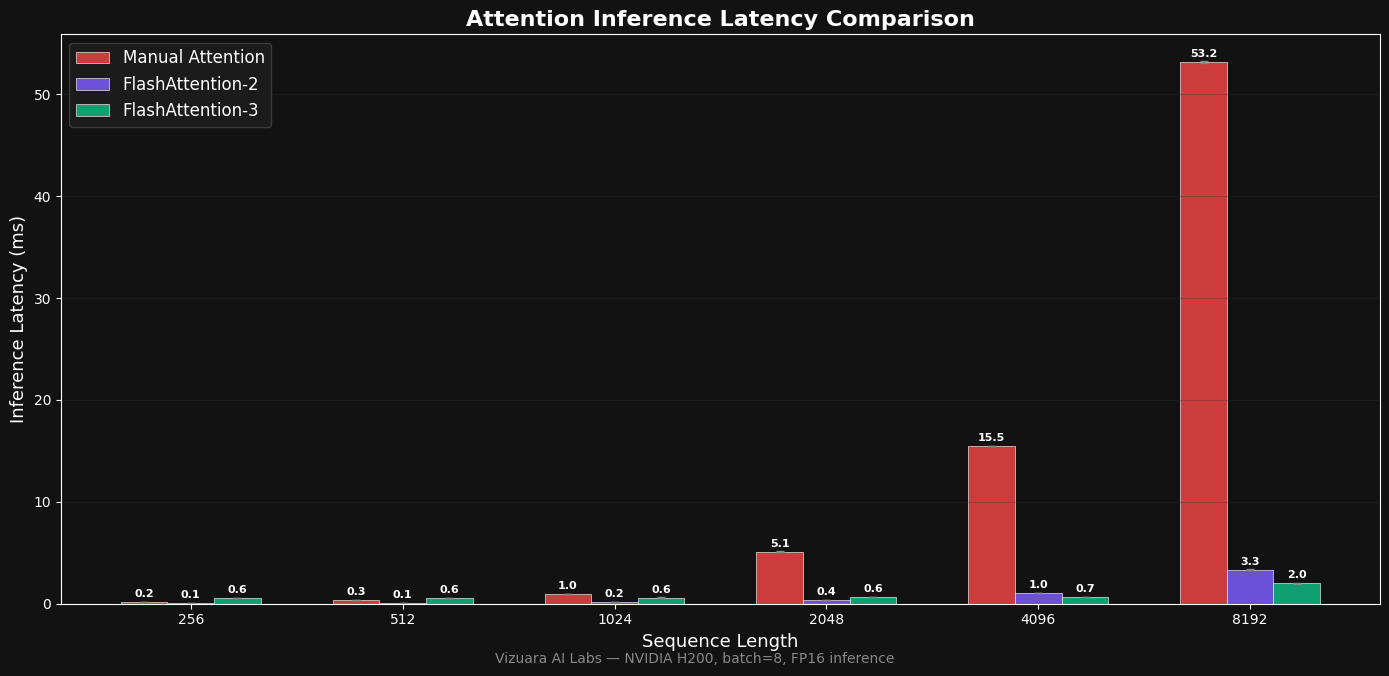

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))

num_variants = len(results)
bar_width = 0.22
x_pos = np.arange(len(SEQ_LENGTHS))

for i, (name, data) in enumerate(results.items()):
    means = [d[1] for d in data]
    stds  = [d[2] for d in data]
    offset = (i - (num_variants - 1) / 2) * bar_width
    bars = ax.bar(x_pos + offset, means, bar_width, yerr=stds,
                  label=name, color=COLORS[name], alpha=0.85,
                  edgecolor="white", linewidth=0.5, capsize=3,
                  error_kw={"ecolor": "#888888"})
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Sequence Length", fontsize=13)
ax.set_ylabel("Inference Latency (ms)", fontsize=13)
ax.set_title("Attention Inference Latency Comparison", fontsize=16, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels([str(s) for s in SEQ_LENGTHS])
ax.legend(fontsize=12)
ax.grid(True, axis="y", alpha=0.3)

fig.suptitle(f"Vizuara AI Labs — {gpu_name}, batch={BATCH_SIZE}, FP16 inference",
             fontsize=10, color="#888888", y=0.02)
plt.tight_layout()
plt.savefig("plot_bar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.5 Theoretical vs Measured HBM I/O

Let's compute the **theoretical HBM bytes transferred** for standard attention vs FlashAttention to connect the benchmark numbers back to the theory from our walkthroughs.

In [16]:
bytes_per_elem = 2  # FP16
d = EMBED_DIM // NUM_HEADS  # head dimension
SRAM_SIZE = 192 * 1024  # ~192KB usable SRAM per SM (A100/H100)

print("=" * 80)
print(f"{'Seq Len':>8}  {'Standard I/O':>14}  {'Flash I/O':>14}  {'Reduction':>10}  {'N×N Matrix':>12}")
print("=" * 80)

for N in SEQ_LENGTHS:
    # Standard attention I/O per head:
    #   Read Q,K: 2×N×d    Write S: N×N    Read S: N×N
    #   Write P: N×N       Read P: N×N     Read V: N×d
    #   Write O: N×d
    # Total = 4×N×d + 4×N² (in elements)
    standard_bytes = (4 * N * d + 4 * N * N) * bytes_per_elem * NUM_HEADS * BATCH_SIZE

    # FlashAttention I/O per head:
    #   Read Q: N×d (once)  Read K,V: 2×N×d × ceil(N/B_q) passes
    #   Write O: N×d (once)
    # Simplified: O(N²d / M) where M = SRAM size
    B = int(min(SRAM_SIZE / (d * bytes_per_elem * 4), N))  # approximate block size
    T_q = math.ceil(N / B)
    T_kv = math.ceil(N / B)
    flash_bytes = (N * d + T_q * 2 * N * d + N * d) * bytes_per_elem * NUM_HEADS * BATCH_SIZE

    reduction = standard_bytes / flash_bytes
    nn_matrix_mb = (N * N * bytes_per_elem * NUM_HEADS * BATCH_SIZE) / (1024**2)

    print(f"{N:>8}  {standard_bytes/1e6:>11.1f} MB  {flash_bytes/1e6:>11.1f} MB  {reduction:>9.1f}×  {nn_matrix_mb:>9.1f} MB")

print("=" * 80)
print(f"\nN×N matrix column = memory needed JUST for the intermediate score matrix (S).")
print(f"This is what FlashAttention eliminates entirely — it never exists in HBM.")


 Seq Len    Standard I/O       Flash I/O   Reduction    N×N Matrix
     256         62.9 MB         12.6 MB        5.0×       12.0 MB
     512        226.5 MB         37.7 MB        6.0×       48.0 MB
    1024        855.6 MB        100.7 MB        8.5×      192.0 MB
    2048       3321.9 MB        352.3 MB        9.4×      768.0 MB
    4096      13086.2 MB       1208.0 MB       10.8×     3072.0 MB
    8192      51942.3 MB       4630.5 MB       11.2×    12288.0 MB

N×N matrix column = memory needed JUST for the intermediate score matrix (S).
This is what FlashAttention eliminates entirely — it never exists in HBM.


In [17]:
import json
from pathlib import Path

benchmark_summary = {
    "environment": {
        "gpu": gpu_name,
        "sm_version": f"sm_{sm_version}",
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "has_fa2": HAS_FA2,
        "has_fa3": HAS_FA3,
    },
    "latency_vs_sequence_ms": {name: data for name, data in results.items()},
    "peak_memory_mb": {name: data for name, data in mem_results.items()},
    "batch_scaling_ms": {name: data for name, data in batch_results.items()},
}

Path("flashattention_benchmark_summary.json").write_text(json.dumps(benchmark_summary, indent=2))
print(json.dumps(benchmark_summary["environment"], indent=2))
print("Saved flashattention_benchmark_summary.json")


{
  "gpu": "NVIDIA H200",
  "sm_version": "sm_90",
  "torch": "2.4.1+cu124",
  "cuda": "12.4",
  "has_fa2": true,
  "has_fa3": true
}
Saved flashattention_benchmark_summary.json


---
## What Are We Measuring And Showing?

The benchmark measures **inference latency** and **peak GPU memory usage** for the attention forward pass. Latency tells us how many milliseconds it takes to run attention for a given batch size and sequence length. Peak memory tells us how much GPU memory is allocated during the forward pass. Manual attention is expected to use much more memory because it materializes the full token-by-token attention matrix in GPU memory. FlashAttention avoids storing that full matrix and instead computes attention in tiles, which is why it is much more memory efficient for long contexts.

The plots make the benchmark results easier to read. The latency-vs-sequence-length plot shows how runtime grows as prompts get longer. The speedup plot compares FA2 and FA3 against manual attention. The memory plot shows how manual attention's memory usage grows sharply with sequence length, while FlashAttention stays much flatter. The batch-size plot shows what happens when we process more prompts together at a fixed sequence length. Together, these plots show why FlashAttention matters for LLM inference: it reduces memory pressure and makes long-context attention much faster, especially on GPUs designed for these kernels.


---
## 10. Summary: Connecting Theory to Practice

### What we observed

| Aspect | Manual Attention | FlashAttention-2 | FlashAttention-3 |
|--------|-----------------|-------------------|-------------------|
| **Algorithm** | Textbook QK^TV | Tiling + online softmax | Same + async HW pipeline |
| **HBM I/O** | O(N² + Nd) — quadratic | O(N²d/M) — reduced by SRAM | Same, but overlapped |
| **Intermediates in HBM** | Full N×N matrix (S, P) | None — tiles stay in SRAM | None |
| **GPU utilization** | ~10% (memory-bound, starved) | 50-73% (A100) | ~75% (H100) |
| **Speedup grows with N** | Baseline | Yes — quadratic savings | Yes — plus HW overlap |
| **Hardware needed** | Any GPU | SM80+ (A100, H100) | SM90 only (H100) |

### Why this matters for inference serving

1. **Prefill latency (TTFT):** The prefill phase processes the entire prompt through attention. At 8K+ tokens, standard attention's O(N²) HBM traffic dominates. FlashAttention directly reduces time-to-first-token.

2. **Max context length:** Standard attention OOMs at long contexts because the N×N matrix doesn't fit in HBM. FlashAttention's O(1) intermediate memory enables 128K+ contexts.

3. **Batch throughput:** Lower per-request memory means you can batch more requests, improving tokens/second/GPU — the key metric for inference cost.

4. **The paradox revisited:** FlashAttention does **more FLOPs** (~14% extra for online softmax corrections) but is **faster** because the GPU was memory-bound — the extra compute is free. This is the roofline model in action.

> **Key takeaway:** FlashAttention doesn't change *what* is computed — it changes *where* (SRAM vs HBM) and *how* (tiled, pipelined). Same math, same results, dramatically less memory traffic.

---

*Vizuara AI Labs — Inference Engineering Workshop*

*Benchmark code adapted from [Sebastian Raschka, "Build a Large Language Model From Scratch"](https://github.com/rasbt/LLMs-from-scratch)*